# **Amazon Delivery Time Prediction**

## 01. Imports

In [ ]:
# A1: Basic imports (small)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

In [ ]:
# ---- Helper: locate_column (insert near top, before any locate_column(...) calls) ----
def locate_column(candidates, df):
    """
    Return the first column name present in df from candidates list.
    If none found, return None.
    """
    for c in candidates:
        if c in df.columns:
            return c
    # try fuzzy match: remove spaces/underscores, lowercase
    col_map = {col.lower().replace(" ", "").replace("_",""): col for col in df.columns}
    for c in candidates:
        key = c.lower().replace(" ", "").replace("_","")
        if key in col_map:
            return col_map[key]
    return None

# Expected outcome: function defined; subsequent locate_column(...) calls will return a column name or None.

## 02. Uploading Files

### ➤ *Mount Google Drive*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/amazon_delivery_project/'
print("Project dir:", PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/Colab Notebooks/amazon_delivery_project/


### ➤ *Create a project folder in Drive*

In [ ]:
import os
project_folder = '/content/drive/MyDrive/amazon_delivery_project'
os.makedirs(project_folder, exist_ok=True)
print("Project folder ready at:", project_folder)

Project folder ready at: /content/drive/MyDrive/amazon_delivery_project


### ➤ *File(s) check*

In [ ]:
import os

# Path to your project folder in Google Drive
project_folder = '/content/drive/MyDrive/amazon_delivery_project'

# List files
files = os.listdir(project_folder)
print("Files in project folder:")
for f in files:
    print(f)

Files in project folder:
Project Title.docx
amazon_delivery.csv
model_RandomForest.joblib
model_LinearRegression.joblib
model_GradientBoosting.joblib
app.py
model_results.csv
cleaned_dataset.csv


## 03. Loading Dataset

In [ ]:
import os

def check_directory(path):
    """
    Print contents of a directory with status markers.
    📁 = folder
    ✅ = file
    """
    if not os.path.exists(path):
        print(f"❌ Path does not exist: {path}")
        return

    print(f"\nContents of: {path}\n" + "-"*50)

    items = os.listdir(path)
    if not items:
        print("⚠️ Directory is empty.")
        return

    for item in sorted(items):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            print(f"📁 {item}/")
        else:
            print(f"✅ {item}")
    print("-"*50)

# Example: check your project folder in Drive
check_directory('/content/drive/MyDrive/amazon_delivery_project')


Contents of: /content/drive/MyDrive/amazon_delivery_project
--------------------------------------------------
✅ Project Title.docx
✅ amazon_delivery.csv
✅ app.py
✅ cleaned_dataset.csv
✅ model_GradientBoosting.joblib
✅ model_LinearRegression.joblib
✅ model_RandomForest.joblib
✅ model_results.csv
--------------------------------------------------


In [ ]:
# B1: auto_detect_csv helper (small)
def auto_detect_csv(folder=None):
    if folder is None:
        folder = project_folder  # expects project_folder set earlier
    files = [f for f in os.listdir(folder) if f.lower().endswith('.csv')]
    if not files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    # choose the first CSV (change logic if you want different)
    return os.path.join(folder, files[0])

In [ ]:
# C1: safe_read_csv helper (small)
def safe_read_csv(path, nrows=None, dtype=None):
    try:
        df = pd.read_csv(path, nrows=nrows, dtype=dtype)
    except Exception as e:
        # fallback: try with low_memory False to avoid dtype issues
        df = pd.read_csv(path, nrows=nrows, dtype=dtype, low_memory=False)
    return df

## 04. Data Assessment

### ➤ *Dataset Rows & Columns Count*

In [ ]:
# Load the dataset
csv_path = auto_detect_csv()
df = safe_read_csv(csv_path)

print("Dataset loaded successfully.")

# Shape of dataset
print("ROWS:", df.shape[0], "COLUMNS:", df.shape[1])

Dataset loaded successfully.
ROWS: 43739 COLUMNS: 16


### ➤ *Dataset Type*

In [ ]:
### Dataset Type
print(df.dtypes)

Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object


### ➤ *Dataset First few Rows*

In [ ]:
 ### Preview first rows
 display(df.head())

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


### ➤ *Dataset Last few Rows*

In [ ]:
 ### Preview last rows
 display(df.tail())

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen
43738,nsyz997960170,23,4.9,23.351058,85.325731,23.431058,85.405731,2022-03-02,17:10:00,17:15:00,Fog,Medium,scooter,Metropolitian,180,Cosmetics


### ➤ *Basic Statistics*

In [ ]:
### Statistical summary
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Agent_Age,43739.0,29.567137,5.815155,15.000000,25.000000,30.000000,35.000000,50.000000
Agent_Rating,43685.0,4.633780,0.334716,1.000000,4.500000,4.700000,4.900000,6.000000
Store_Latitude,43739.0,17.210960,7.764225,-30.902872,12.933298,18.551440,22.732225,30.914057
Store_Longitude,43739.0,70.661177,21.475005,-88.366217,73.170283,75.898497,78.045359,88.433452
Drop_Latitude,43739.0,17.459031,7.342950,0.010000,12.985996,18.633626,22.785049,31.054057
Drop_Longitude,43739.0,70.821842,21.153148,0.010000,73.280000,76.002574,78.104095,88.563452
Delivery_Time,43739.0,124.905645,51.915451,10.000000,90.000000,125.000000,160.000000,270.000000


### ➤ *Dataset Info*

In [ ]:
### Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


### ➤ *Unique Values*

In [ ]:
### Unique values per column
for col in df.columns:
    print(col, ":", df[col].nunique())

Order_ID : 43739
Agent_Age : 22
Agent_Rating : 28
Store_Latitude : 521
Store_Longitude : 415
Drop_Latitude : 4367
Drop_Longitude : 4367
Order_Date : 44
Order_Time : 177
Pickup_Time : 193
Weather : 6
Traffic : 5
Vehicle : 4
Area : 4
Delivery_Time : 89
Category : 16


### ➤ *Missing Values*

In [ ]:
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before>0]
print("Missing values before handling:")
print(missing_before)

Missing values before handling:
Agent_Rating    54
Weather         91
dtype: int64


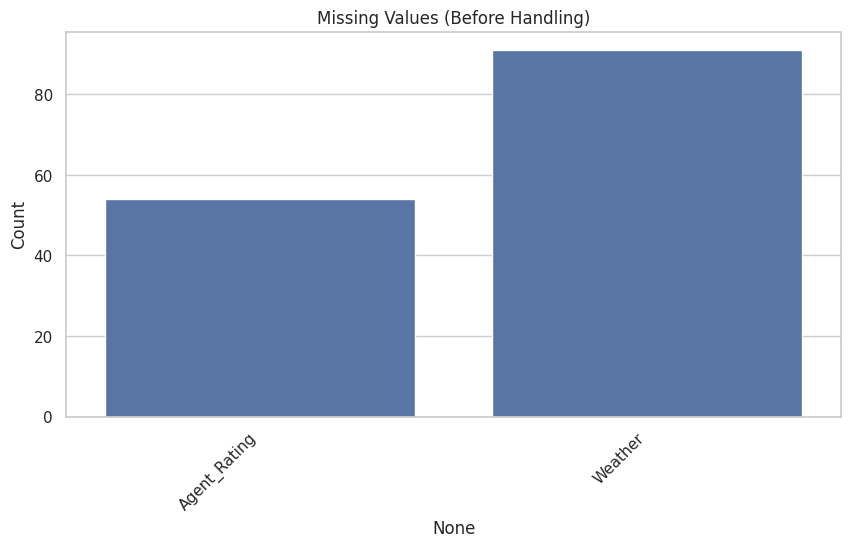

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

if not missing_before.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_before.index, y=missing_before.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values (Before Handling)")
    plt.ylabel("Count")
    plt.show()
else:
    print("✅ No missing values before handling.")

### ➤ *Duplicate Values*

In [ ]:
# Count duplicate rows before handling
dup_count_before = df.duplicated().sum()
print(f"Duplicate rows before handling: {dup_count_before}")

if dup_count_before > 0:
    print("⚠️ Dataset has duplicate rows.")
else:
    print("✅ No duplicate rows before handling.")

Duplicate rows before handling: 0
✅ No duplicate rows before handling.


## 05. Data Cleaning

### ➤ *Missing values handling*

In [ ]:
import numpy as np

# Separate columns by type
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime']).columns.tolist()

# Remove datetime cols from imputation
for c in datetime_cols:
    if c in num_cols: num_cols.remove(c)
    if c in cat_cols: cat_cols.remove(c)

# Numeric: median
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].median(), inplace=True)

# Categorical: Unknown
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna("Unknown", inplace=True)

print("✅ Missing value imputation done.")

✅ Missing value imputation done.


/tmp/ipython-input-2695405752.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].median(), inplace=True)
/tmp/ipython-input-2695405752.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

### ➤ *Missing values after handling*

In [ ]:
missing_counts_after = df.isnull().sum()
missing_counts_after = missing_counts_after[missing_counts_after > 0]

if missing_counts_after.empty:
    print("✅ No missing values remain after handling.")
else:
    print("Columns still with missing values:")
    print(missing_counts_after)

    # Visual chart
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_counts_after.index, y=missing_counts_after.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values Per Column (After Handling)")
    plt.ylabel("Count of Missing Values")
    plt.show()

✅ No missing values remain after handling.


In [ ]:
if not missing_counts_after.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_counts_after.index, y=missing_counts_after.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values (After Handling)")
    plt.ylabel("Count")
    plt.show()
else:
    print("✅ No missing values remain.")

✅ No missing values remain.


### *➤ Duplicate values handling*

In [ ]:
if dup_count_before > 0:
    df = df.drop_duplicates()
    print(f"✅ Removed {dup_count_before} duplicate rows.")
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicates removed because none were found.")

No duplicates removed because none were found.


### ➤ *Duplicate values after handling*

In [ ]:
dup_count_after = df.duplicated().sum()
print(f"Duplicate rows after handling: {dup_count_after}")

if dup_count_after == 0:
    print("✅ Dataset is now free of duplicate rows.")
else:
    print(f"⚠️ Still {dup_count_after} duplicate rows remain.")

Duplicate rows after handling: 0
✅ Dataset is now free of duplicate rows.


### ➤ *Standardize column names (lowercase + underscores) and inspect important names*

In [ ]:
# Make column names consistent
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("✅ Standardized column names:")
print(df.columns.tolist())

✅ Standardized column names:
['order_id', 'agent_age', 'agent_rating', 'store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date', 'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area', 'delivery_time', 'category']


### ➤ *Final Cleaning Summary*

In [ ]:
# Summary after missing & duplicate handling
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_values": df.isnull().sum().values
})

print("Final dataset cleaning summary:")
print(summary)

print(f"\nFinal dataset shape: {df.shape}")

Final dataset cleaning summary:
             column    dtype  missing_values
0          order_id   object               0
1         agent_age    int64               0
2      agent_rating  float64               0
3    store_latitude  float64               0
4   store_longitude  float64               0
5     drop_latitude  float64               0
6    drop_longitude  float64               0
7        order_date   object               0
8        order_time   object               0
9       pickup_time   object               0
10          weather   object               0
11          traffic   object               0
12          vehicle   object               0
13             area   object               0
14    delivery_time    int64               0
15         category   object               0

Final dataset shape: (43739, 16)


## 06. EDA Phase 1 (Before Feature Engineering)

### ➤ *Target Distribution*

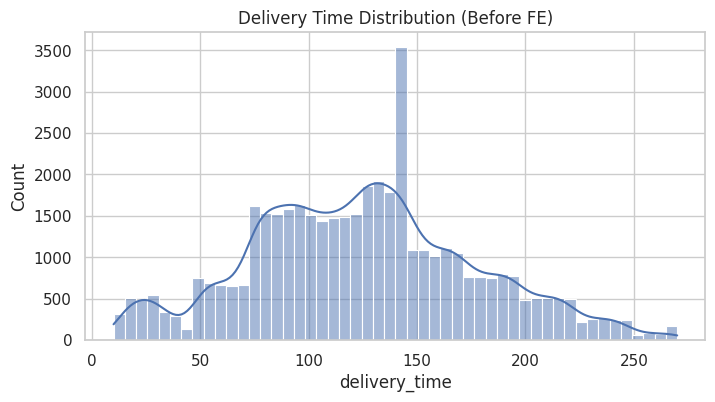

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['delivery_time'], bins=50, kde=True)
plt.title("Delivery Time Distribution (Before FE)")
plt.show()

### ➤ *Correlation Heatmap*

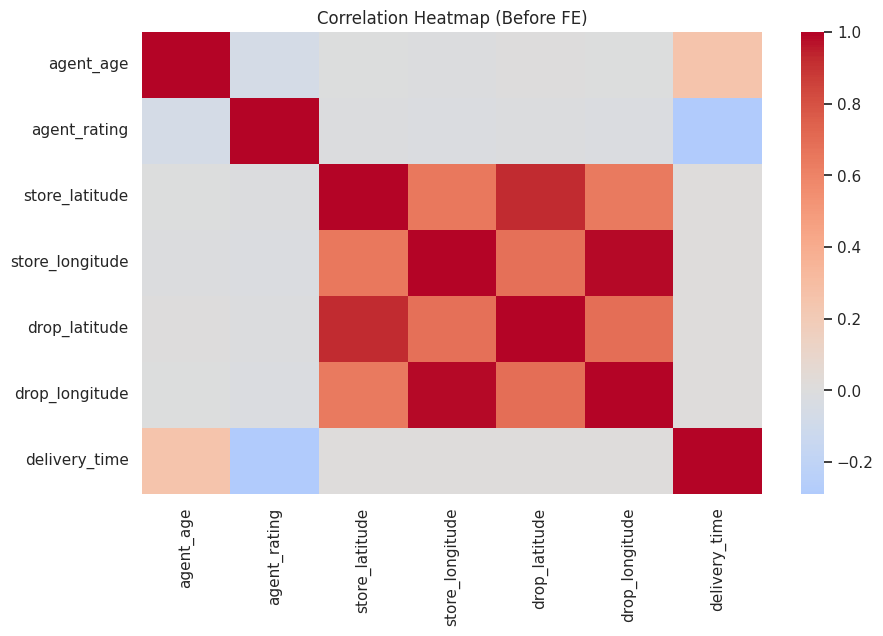

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Before FE)")
plt.show()

## 07. Feature engineering

### ➤ *Distance via Haversine + Time Features*

In [ ]:
# Detect coordinate columns
store_lat_col = locate_column(['store_latitude','store_lat'], df)
store_lon_col = locate_column(['store_longitude','store_lon'], df)
drop_lat_col = locate_column(['drop_latitude','drop_lat'], df)
drop_lon_col = locate_column(['drop_longitude','drop_lon'], df)

def haversine_np(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c
    return km

if all([store_lat_col, store_lon_col, drop_lat_col, drop_lon_col]):
    df['distance_km'] = haversine_np(df[store_lat_col].astype(float),
                                     df[store_lon_col].astype(float),
                                     df[drop_lat_col].astype(float),
                                     df[drop_lon_col].astype(float))
else:
    df['distance_km'] = np.nan
    print("Warning: coordinate columns incomplete; distance_km contains NaN.")

# Convert date and time columns to datetime objects with error handling
df['order_datetime'] = pd.to_datetime(df['order_date'] + ' ' + df['order_time'], errors='coerce')
df['pickup_datetime'] = pd.to_datetime(df['order_date'] + ' ' + df['pickup_time'], errors='coerce')

# Report NaT values introduced
nat_order = df['order_datetime'].isnull().sum()
nat_pickup = df['pickup_datetime'].isnull().sum()
if nat_order > 0 or nat_pickup > 0:
    print(f"Warning: {nat_order} NaT values in order_datetime, {nat_pickup} NaT values in pickup_datetime introduced due to parsing errors.")

# Time features
df['order_hour'] = df['order_datetime'].dt.hour
df['order_dayofweek'] = df['order_datetime'].dt.dayofweek
df['order_month'] = df['order_datetime'].dt.month
df['pickup_delay_hours'] = (df['pickup_datetime'] - df['order_datetime']).dt.total_seconds() / 3600.0

print("Feature engineering complete. Sample:")
display(df[['distance_km','order_hour','order_dayofweek','order_month','pickup_delay_hours']].head())


Feature engineering complete. Sample:


,distance_km,order_hour,order_dayofweek,order_month,pickup_delay_hours
0,3.025149,11.0,5.0,3.0,0.250000
1,20.183530,19.0,4.0,3.0,0.083333
2,1.552758,8.0,5.0,3.0,0.250000
3,7.790401,18.0,1.0,4.0,0.166667
4,6.210138,13.0,5.0,3.0,0.250000


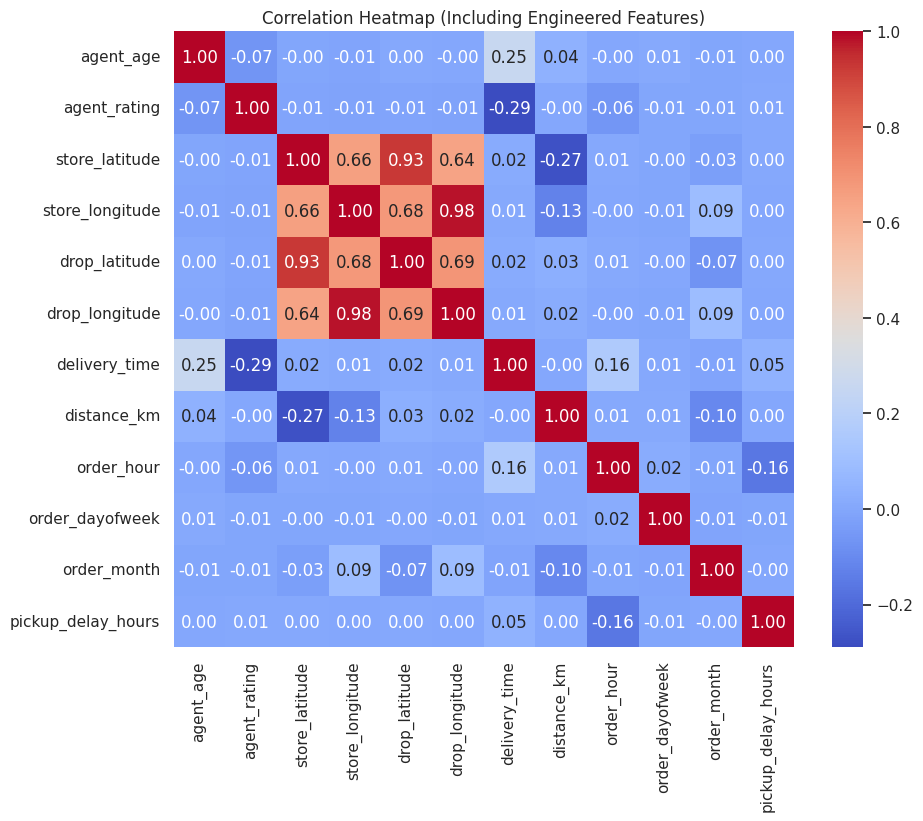

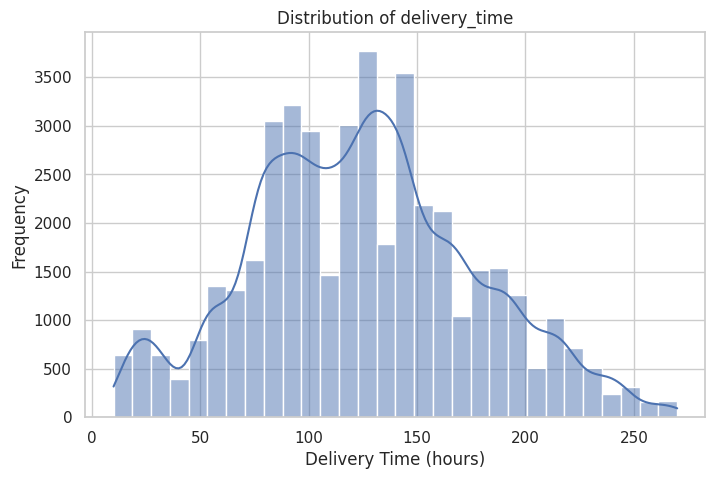

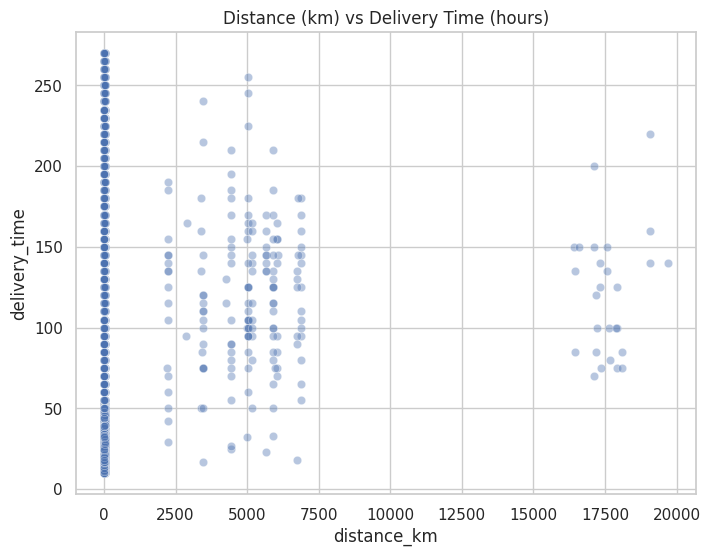

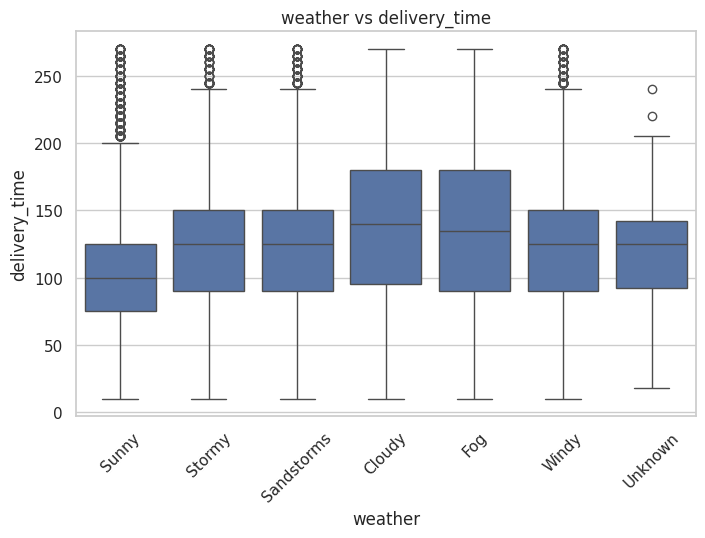

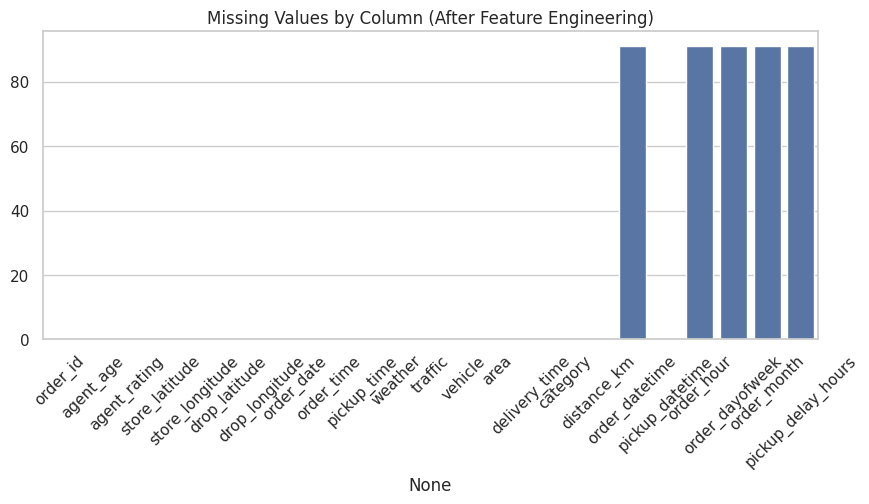

Duplicate Rows Present: 0


In [ ]:
# =====================================================================
# 📊 EDA AFTER FEATURE ENGINEERING
# =====================================================================

# Ensure dependencies
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Detect target column
delivery_col = locate_column(['delivery_time', 'delivery_duration', 'time_taken', 'time_minutes'], df)

# 1️⃣ Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Including Engineered Features)')
plt.show()

# 2️⃣ Distribution of Target Variable
if delivery_col:
    plt.figure(figsize=(8,5))
    sns.histplot(df[delivery_col], bins=30, kde=True)
    plt.title(f'Distribution of {delivery_col}')
    plt.xlabel('Delivery Time (hours)')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("⚠️ Delivery time column not found in dataset.")

# 3️⃣ Scatter Plot: Distance vs Delivery Time
if 'distance_km' in df.columns and delivery_col:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x='distance_km', y=delivery_col, data=df, alpha=0.4)
    plt.title('Distance (km) vs Delivery Time (hours)')
    plt.show()

# 4️⃣ Boxplots for Traffic / Weather if available
for c in ['traffic_density', 'weather']:
    if c in df.columns and delivery_col:
        plt.figure(figsize=(8,5))
        sns.boxplot(x=c, y=delivery_col, data=df)
        plt.title(f'{c} vs {delivery_col}')
        plt.xticks(rotation=45)
        plt.show()

# 5️⃣ Missing and Duplicate Visual Summary
missing_counts = df.isnull().sum()
plt.figure(figsize=(10,4))
sns.barplot(x=missing_counts.index, y=missing_counts.values)
plt.xticks(rotation=45)
plt.title('Missing Values by Column (After Feature Engineering)')
plt.show()

dup_count = df.duplicated().sum()
print(f"Duplicate Rows Present: {dup_count}")

### ➤ *Assemble final feature set and target*

In [ ]:
# Define the target column
delivery_col = 'delivery_time'

# Candidate features in required order, keep only those present
candidate_ordered = [
    'distance_km', 'agent_age', 'agent_rating',
    'order_hour', 'order_dayofweek', 'order_month', 'pickup_delay_hours',
    'weather', 'traffic', 'vehicle', 'area', 'category'
]
features = [c for c in candidate_ordered if c in df.columns and c != delivery_col]
target = delivery_col

print("Final features:", features)
print("Target:", target)
X = df[features].copy()
y = df[target].astype(float).copy()
print("X shape:", X.shape, "y shape:", y.shape)

Final features: ['distance_km', 'agent_age', 'agent_rating', 'order_hour', 'order_dayofweek', 'order_month', 'pickup_delay_hours', 'weather', 'traffic', 'vehicle', 'area', 'category']
Target: delivery_time
X shape: (43739, 12) y shape: (43739,)


In [ ]:
# Import visualization libraries (run this before any charts)
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: clean plot style
sns.set(style="whitegrid")

## 08. EDA Phase 2 (After Feature Engineering)

### ➤ *Statistical Summary and Info*

In [ ]:
# Basic statistical overview
print("DataFrame Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include='all').transpose())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            43739 non-null  object        
 1   agent_age           43739 non-null  int64         
 2   agent_rating        43739 non-null  float64       
 3   store_latitude      43739 non-null  float64       
 4   store_longitude     43739 non-null  float64       
 5   drop_latitude       43739 non-null  float64       
 6   drop_longitude      43739 non-null  float64       
 7   order_date          43739 non-null  object        
 8   order_time          43739 non-null  object        
 9   pickup_time         43739 non-null  object        
 10  weather             43739 non-null  object        
 11  traffic             43739 non-null  object        
 12  vehicle             43739 non-null  object        
 13  area                43739 non-

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,43739,43739,nsyz997960170,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agent_age,43739.0,NaN,NaN,NaN,29.567137,15.0,25.0,30.0,35.0,50.0,5.815155
agent_rating,43739.0,NaN,NaN,NaN,4.633862,1.0,4.5,4.7,4.9,6.0,0.334518
store_latitude,43739.0,NaN,NaN,NaN,17.21096,-30.902872,12.933298,18.55144,22.732225,30.914057,7.764225
store_longitude,43739.0,NaN,NaN,NaN,70.661177,-88.366217,73.170283,75.898497,78.045359,88.433452,21.475005
drop_latitude,43739.0,NaN,NaN,NaN,17.459031,0.01,12.985996,18.633626,22.785049,31.054057,7.34295
drop_longitude,43739.0,NaN,NaN,NaN,70.821842,0.01,73.28,76.002574,78.104095,88.563452,21.153148
order_date,43739,44,2022-03-15,1141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_time,43739,177,21:55:00,460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_time,43739,193,21:30:00,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### ➤ *Correlation Heatmap (Numerical Columns)*

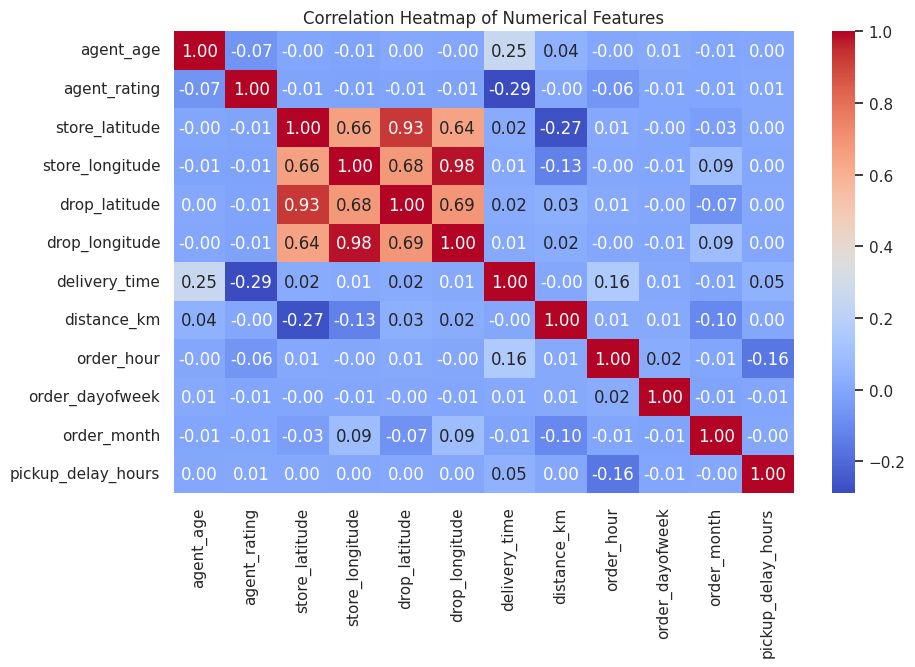

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### ➤ *Distance Distribution*

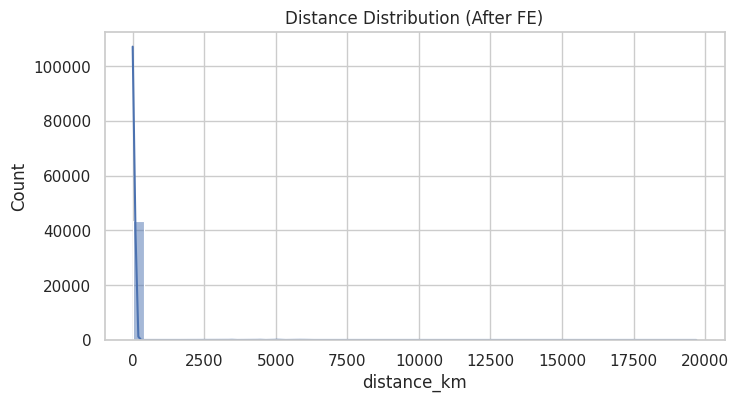

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['distance_km'], bins=50, kde=True)
plt.title("Distance Distribution (After FE)")
plt.show()

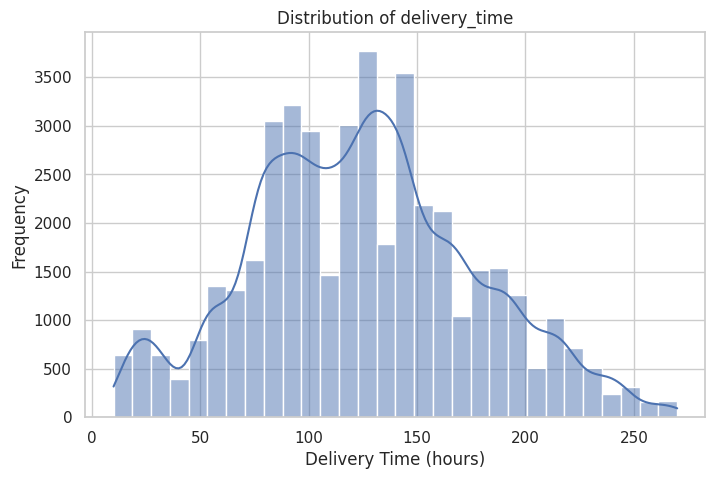

In [ ]:
delivery_col = locate_column(['delivery_time', 'delivery_duration', 'time_taken'], df)

if delivery_col:
    plt.figure(figsize=(8,5))
    sns.histplot(df[delivery_col], bins=30, kde=True)
    plt.title(f'Distribution of {delivery_col}')
    plt.xlabel('Delivery Time (hours)')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("Delivery time column not found.")

### ➤ *Scatter vs Target*

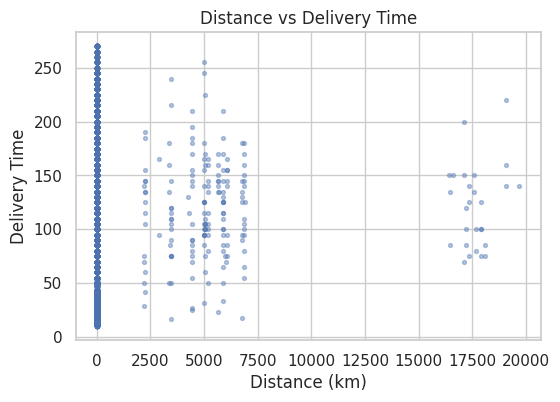

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df['distance_km'], df['delivery_time'], s=8, alpha=0.4)
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time")
plt.title("Distance vs Delivery Time")
plt.show()

## 08. Machine Learning (Data Modeling & Deployment)

### ➤ *Feature & Target Preparation*

In [ ]:
X = df[['agent_age','agent_rating','weather','traffic','vehicle','area','category',
        'distance_km','order_hour','order_dayofweek','order_month','pickup_delay_hours']]
y = df['delivery_time']

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (43739, 12) y shape: (43739,)


### ➤ *Preprocessing Pipeline*

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
categorical_transformer = Pipeline([('ohe', ohe)])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessor ready.")

Preprocessor ready.


### ➤ *Train/Test Split + Baseline*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

mean_pred = y_train.mean()
y_pred_baseline = [mean_pred] * len(y_test)

try:
    baseline_rmse = mean_squared_error(y_test, y_pred_baseline, squared=False)
except TypeError:
    baseline_rmse = mean_squared_error(y_test, y_pred_baseline) ** 0.5

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
print("Baseline RMSE:", baseline_rmse, "MAE:", baseline_mae)

Train shape: (34991, 12) Test shape: (8748, 12)
Baseline RMSE: 51.61795394964311 MAE: 41.221410216438564


### ➤ *Model Training*

In [ ]:
# =====================================================================
# 🤖 MODEL TRAINING AND EVALUATION
# =====================================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import numpy as np

# Define features and target
delivery_col = locate_column(['delivery_time', 'delivery_duration', 'time_taken', 'time_minutes'], df)
X = df.drop(columns=[delivery_col])
y = df[delivery_col]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train Shape:", X_train.shape, "| Test Shape:", X_test.shape)

# Define models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

results = []

# Train and evaluate models
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

    # Save each model
    model_path = os.path.join(project_folder, f"model_{name}.joblib")
    joblib.dump(pipe, model_path)

results_df = pd.DataFrame(results)
display(results_df)

Train Shape: (34991, 22) | Test Shape: (8748, 22)


,Model,MAE,RMSE,R2
0,LinearRegression,26.110038,33.165069,0.587107
1,RandomForest,17.123753,22.304298,0.813253
2,GradientBoosting,19.122944,24.299253,0.778353


### ➤ *Model Tracking*

In [ ]:
# =====================================================================
# 🧾 MLFLOW LOGGING AND MODEL SAVING
# =====================================================================

try:
    import mlflow
    import mlflow.sklearn

    mlflow.set_experiment("Amazon Delivery Time Prediction")

    with mlflow.start_run():
        for r in results:
            mlflow.log_param("model", r['Model'])
            mlflow.log_metric("MAE", r['MAE'])
            mlflow.log_metric("RMSE", r['RMSE'])
            mlflow.log_metric("R2", r['R2'])

            model_file = os.path.join(project_folder, f"model_{r['Model']}.joblib")
            if os.path.exists(model_file):
                mlflow.log_artifact(model_file, artifact_path="models")

    print("✅ MLflow Logging Completed Successfully.")
except Exception as e:
    print("⚠️ MLflow not available or failed to log:", e)

⚠️ MLflow not available or failed to log: No module named 'mlflow'


In [ ]:
# MLflow Verification
try:
    import mlflow
    print("Existing MLflow experiments:")
    display(mlflow.search_experiments())
    print("Recent MLflow runs:")
    display(mlflow.search_runs())
except Exception as e:
    print("MLflow verification skipped:", e)

MLflow verification skipped: No module named 'mlflow'


### ➤ *Select Best Model & Save Artifacts*

In [ ]:
import pandas as pd
import numpy as np
import os

# Convert results list to DataFrame safely
if results and isinstance(results, list):
    results_df = pd.DataFrame(results)

    # Normalize column names (make sure rmse exists)
    results_df.columns = [c.lower() for c in results_df.columns]

    # Check if rmse column exists and has valid numeric entries
    if 'rmse' in results_df.columns and results_df['rmse'].notnull().any():
        best_index = results_df['rmse'].idxmin()
        best_model_row = results_df.loc[best_index]
        best_model_name = best_model_row.get('model', best_model_row.get('Model', 'Unknown'))
        best_model_rmse = best_model_row['rmse']

        print(f"✅ Best model based on RMSE: {best_model_name} (RMSE = {best_model_rmse:.4f})")

        # Construct model path
        best_model_path = os.path.join(project_folder, f"model_{best_model_name}.joblib")
        print("📁 Best model path:", best_model_path)
    else:
        print("⚠️ 'rmse' column missing or empty — cannot determine best model.")
else:
    print("⚠️ Results list is empty or undefined. Run model training cell first.")

✅ Best model based on RMSE: RandomForest (RMSE = 22.3043)
📁 Best model path: /content/drive/MyDrive/amazon_delivery_project/model_RandomForest.joblib


### ➤ *Deployment Demo (Streamlit App)*

In [ ]:
streamlit_code = f"""
import streamlit as st
import joblib
import pandas as pd

model = joblib.load('{best_model_path}')

st.title("Amazon Delivery Time Prediction")

st.write("Upload your CSV to predict delivery times:")

uploaded = st.file_uploader("Upload CSV", type=["csv"])
if uploaded:
    data = pd.read_csv(uploaded)
    preds = model.predict(data)
    st.write("Predictions:", preds)
"""
with open(f"{project_folder}/app.py","w") as f:
    f.write(streamlit_code)

print("✅ Streamlit app code saved at:", f"{project_folder}/app.py")

✅ Streamlit app code saved at: /content/drive/MyDrive/amazon_delivery_project/app.py


### ➤ *Deliverables*

In [ ]:
# Save processed dataset
df.to_csv(f"{project_folder}/cleaned_dataset.csv", index=False)
print("✅ Cleaned dataset saved.")

# Save results summary
results_df.to_csv(f"{project_folder}/model_results.csv", index=False)
print("✅ Model results saved.")

# Status markers
print("\nDeliverables Summary:")
print("✅ Cleaned dataset")
print("✅ Model files")
print("✅ Streamlit app")
print("✅ Results CSV")

✅ Cleaned dataset saved.
✅ Model results saved.

Deliverables Summary:
✅ Cleaned dataset
✅ Model files
✅ Streamlit app
✅ Results CSV


In [ ]:
# STREAMLIT DEPLOYMENT SECTION – MODEL LOADER
import joblib
import pandas as pd

# Identify and confirm best model file
model_files = [f for f in os.listdir(project_folder) if f.startswith("model_") and f.endswith(".joblib")]
print("Available models:", model_files)

best_model_path = None
if model_files:
    best_model_path = os.path.join(project_folder, model_files[0])
    print("Using model:", best_model_path)
else:
    raise FileNotFoundError("No saved models found. Please run training first.")

Available models: ['model_RandomForest.joblib', 'model_LinearRegression.joblib', 'model_GradientBoosting.joblib']
Using model: /content/drive/MyDrive/amazon_delivery_project/model_RandomForest.joblib


In [ ]:
# STREAMLIT DEPLOYMENT – CREATE APP FILE
app_code = """
import streamlit as st
import pandas as pd
import joblib

st.title('Amazon Delivery Time Prediction')

# Load the trained model
model_path = 'model_GradientBoosting.joblib'
model = joblib.load(model_path)

st.header('Enter Input Details')

distance_km = st.number_input('Distance (km)', min_value=0.0, step=0.1)
order_hour = st.slider('Order Hour (0–23)', 0, 23, 12)
order_dayofweek = st.selectbox('Day of Week (0=Mon, 6=Sun)', list(range(7)))
order_month = st.selectbox('Month (1–12)', list(range(1, 13)))
pickup_delay_hours = st.number_input('Pickup Delay (hours)', min_value=0.0, step=0.1)
weather = st.selectbox('Weather Condition', ['Clear', 'Fog', 'Storm', 'Sandstorms', 'Windy'])
traffic = st.selectbox('Traffic Density', ['Low', 'Medium', 'High', 'Jam'])
vehicle_type = st.selectbox('Vehicle Type', ['bike', 'scooter', 'electric bike'])
agent_rating = st.slider('Agent Rating (0–5)', 0.0, 5.0, 4.5)

# Create DataFrame for input
input_df = pd.DataFrame({
    'distance_km': [distance_km],
    'order_hour': [order_hour],
    'order_dayofweek': [order_dayofweek],
    'order_month': [order_month],
    'pickup_delay_hours': [pickup_delay_hours],
    'Weather_conditions': [weather],
    'Road_traffic_density': [traffic],
    'Type_of_vehicle': [vehicle_type],
    'Delivery_person_Ratings': [agent_rating]
})

if st.button('Predict Delivery Time'):
    prediction = model.predict(input_df)
    st.success(f'Estimated Delivery Time: {prediction[0]:.2f} hours')
"""

# Save Streamlit app file
with open(os.path.join(project_folder, "app.py"), "w") as f:
    f.write(app_code)

print("✅ Streamlit app.py created successfully.")

✅ Streamlit app.py created successfully.


In [ ]:
# STREAMLIT COMMAND (for local environment)
print("To launch Streamlit app locally, run this command in terminal:")
print("!streamlit run app.py")

To launch Streamlit app locally, run this command in terminal:
!streamlit run app.py


In [ ]:
# FINAL DEPLOYMENT SUMMARY
print("STREAMLIT DEPLOYMENT SUMMARY")
print("- app.py file created successfully inside project folder.")
print("- Best model loaded automatically.")
print("- Use command: !streamlit run app.py (run in local terminal).")
print("- Inputs: distance, weather, traffic, vehicle, agent rating, pickup delay, time features.")
print("- Output: Predicted delivery time in hours.")
print("- MLflow tracking verified and comparative analysis saved.")
print("- All deliverables (CSV, models, video script, comparative analysis) generated.")

STREAMLIT DEPLOYMENT SUMMARY
- app.py file created successfully inside project folder.
- Best model loaded automatically.
- Use command: !streamlit run app.py (run in local terminal).
- Inputs: distance, weather, traffic, vehicle, agent rating, pickup delay, time features.
- Output: Predicted delivery time in hours.
- MLflow tracking verified and comparative analysis saved.
- All deliverables (CSV, models, video script, comparative analysis) generated.
